## Parte 1 ##
Para toda esta parte del laboratorio, considere la red vial de Santiago obtenida a trav´es de OpenStreetMap
como fuente de datos.

In [1]:
# importación de librerías
import geopandas as gpd
import numpy as np
import pandas as pd
import folium
import networkx as nx
import random
import time
import matplotlib.pyplot as plt
import osmnx as ox
from folium.plugins import MarkerCluster, HeatMap
from IPython.display import display
from itertools import permutations
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import unary_union

import warnings
warnings.filterwarnings('ignore')

In [2]:
atropellos_2020 = gpd.read_file("Data_L5/Accidentes/Atropellos_2020.geojson")
bicicletas_2019 = gpd.read_file("Data_L5/Accidentes/Bicicletas_2019.geojson")
motocicletas_2019 = gpd.read_file("Data_L5/Accidentes/Motocicletas_2019.geojson")
puntos_criticos_2019 = gpd.read_file("Data_L5/Accidentes/Puntos_Criticos_2019.geojson")
areas_urbanas = gpd.read_file("Data_L5/Areas Urbanas/areas_urbanas.shp")
comunas = gpd.read_file("Data_L5/Comunas/comunas.shp")
distritos_censales = gpd.read_file("Data_L5/Distritos Censales/Distritos Censales RM.shp")
centroides_distritos_censales = gpd.read_file("Data_L5/Distritos Censales//centroides Distritos Censales RM.shp")
estaciones_metro = gpd.read_file("Data_L5/Metro 2020/Estaciones_2020/Estaciones_2020.shp")
lineas_metro = gpd.read_file("Data_L5/Metro 2020/Lineas_2020/Lineas_2020.shp")
seguridad = pd.read_csv("Data_L5/Seguridad/seguridad_santiago.csv")
seguridad = gpd.GeoDataFrame(seguridad, geometry=gpd.points_from_xy(seguridad.lon, seguridad.lat), crs='EPSG:4326')

In [3]:
# pasar todos al mismo sistema de coordenadas
atropellos_2020 = atropellos_2020.to_crs(epsg=4326)
bicicletas_2019 = bicicletas_2019.to_crs(epsg=4326)
motocicletas_2019 = motocicletas_2019.to_crs(epsg=4326)
puntos_criticos_2019 = puntos_criticos_2019.to_crs(epsg=4326)
areas_urbanas = areas_urbanas.to_crs(epsg=4326)
comunas = comunas.to_crs(epsg=4326)
distritos_censales = distritos_censales.to_crs(epsg=4326)
centroides_distritos_censales = centroides_distritos_censales.to_crs(epsg=4326)
estaciones_metro = estaciones_metro.to_crs(epsg=4326)
lineas_metro = lineas_metro.to_crs(epsg=4326)
seguridad = seguridad.to_crs(epsg=4326)

**a)** 
Usando la red de calles obtenida con OSMnx la comuna de Providencia, identifica las intersecciones (nodos) más críticas (percentil 90) según la centralidad de intermediación (betweenness centrality). Visualice
estos nodos en un mapa junto a los puntos críticos de accidentes y, luego, realice un análisis simple de
cómo se relacionan visualmente.
Bases de datos: OSMnx, Puntos criticos 2019.geojson

In [4]:
# primero, obtenemos el área urbana de Santiago
santiago_urbano = areas_urbanas.loc[areas_urbanas['NOMBRE']=='Santiago']
santiago_urbano = santiago_urbano.to_crs("EPSG:4326")
santiago_urbano

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
385,Santiago,Ciudad,427491.444262,5.821041e+08,"MULTIPOLYGON (((-70.73663 -33.37176, -70.73834..."


In [5]:
# ahora, vemos Providencia
comuna_providencia = comunas.loc[comunas['Comuna']=='Providencia']
comuna_providencia = comuna_providencia.to_crs("EPSG:4326")
comuna_providencia

,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
82,324,16072.408276,10,7,13123,13,2.073083e+07,19223.740933,Región Metropolitana de Santiago,Providencia,Santiago,"POLYGON ((-70.58484 -33.43126, -70.58445 -33.4..."


In [6]:
# a partir de su geometria, podemos obtener el polígono que la representa
poligono_providencia = comuna_providencia.geometry.iloc[0]

# ahora, creamos un grafo de la comuna de Providencia
G = ox.graph_from_polygon(poligono_providencia, network_type="drive")

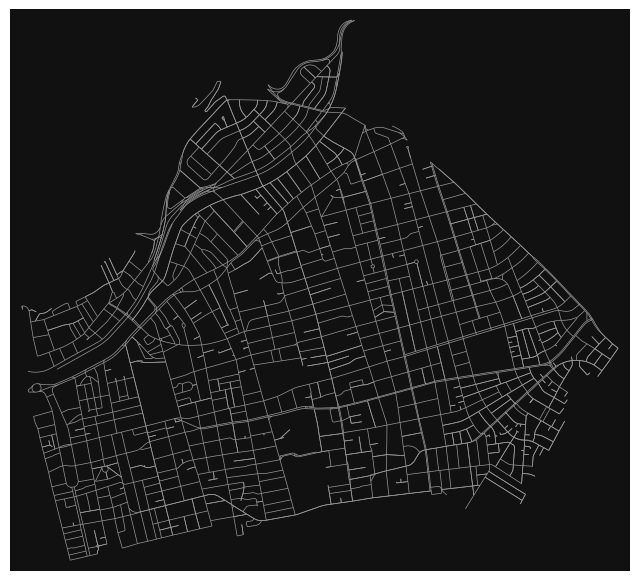

In [7]:
# y lo visualizamos
fig, ax = ox.plot_graph(G, show=False, close=False, edge_color="#999999", edge_linewidth=0.5, node_size=0)

In [ ]:
# ahora la idea es identificar los nodos más críticos según lo que nos piden: centralidad de intermediación

G_undirected = G.to_undirected() # se convierte a grafo no dirigido

# calculamos la centralidad de grado
degree_centrality = nx.degree_centrality(G_undirected)

# luego, la centralidad de cercanía
closeness_centrality = nx.closeness_centrality(G_undirected)

# finalmente, la centralidad de intermediación
betweenness_centrality = nx.betweenness_centrality(G_undirected, normalized=True)

# mostramos los resultados para los primeros 5 nodos
for i, node in enumerate(G_undirected.nodes):
    if i == 5:
        break
    print(f"Nodo: {node}")
    print(f"  Centralidad de Grado: {degree_centrality[node]:.4f}")
    print(f"  Centralidad de Cercanía: {closeness_centrality[node]:.4f}")
    print(f"  Centralidad de Intermediación: {betweenness_centrality[node]:.4f}")
    print()

Nodo: 388703
  Centralidad de Grado: 0.0025
  Centralidad de Cercanía: 0.0376
  Centralidad de Intermediación: 0.0144

Nodo: 388705
  Centralidad de Grado: 0.0019
  Centralidad de Cercanía: 0.0345
  Centralidad de Intermediación: 0.0056

Nodo: 13876993
  Centralidad de Grado: 0.0019
  Centralidad de Cercanía: 0.0490
  Centralidad de Intermediación: 0.0807

Nodo: 13876995
  Centralidad de Grado: 0.0025
  Centralidad de Cercanía: 0.0553
  Centralidad de Intermediación: 0.0592

Nodo: 13876998
  Centralidad de Grado: 0.0025
  Centralidad de Cercanía: 0.0520
  Centralidad de Intermediación: 0.0042



In [9]:
ox.settings.log_console=True

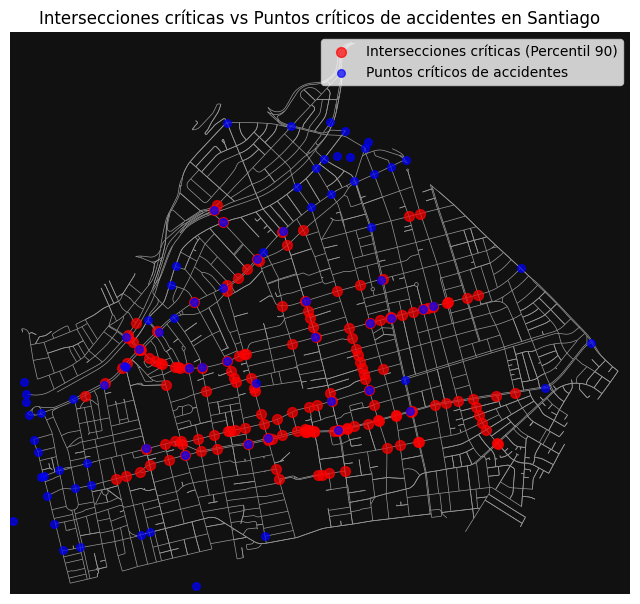

Relación entre intersecciones críticas y puntos críticos de accidentes:
Intersección 3: Centralidad: 0.0450, Distancia al punto crítico más cercano: 202.40 metros
Intersección 4: Centralidad: 0.0665, Distancia al punto crítico más cercano: 310.93 metros
Intersección 24: Centralidad: 0.0594, Distancia al punto crítico más cercano: 384.52 metros
Intersección 28: Centralidad: 0.0494, Distancia al punto crítico más cercano: 272.35 metros
Intersección 29: Centralidad: 0.0933, Distancia al punto crítico más cercano: 9.84 metros
Intersección 30: Centralidad: 0.0407, Distancia al punto crítico más cercano: 236.33 metros
Intersección 33: Centralidad: 0.0488, Distancia al punto crítico más cercano: 115.14 metros
Intersección 40: Centralidad: 0.0657, Distancia al punto crítico más cercano: 2.36 metros
Intersección 44: Centralidad: 0.1020, Distancia al punto crítico más cercano: 182.69 metros
Intersección 45: Centralidad: 0.0857, Distancia al punto crítico más cercano: 237.25 metros
Intersección 4

In [10]:
# se calcula la centralidad de intermediación, pero ponderada por length
betweenness_centrality = nx.betweenness_centrality(G_undirected, weight='length', normalized=True)

# se convierten los valores de centralidad a un GeoDataFrame
centrality_df = gpd.GeoDataFrame(
    {'node': list(betweenness_centrality.keys()),
     'centrality': list(betweenness_centrality.values()),
     'geometry': [Point(G.nodes[node]['x'], G.nodes[node]['y']) for node in betweenness_centrality]},
    crs='EPSG:4326'
)

# se filtran solo las intersecciones críticas en el percentil 90 o superior
percentil_90 = centrality_df['centrality'].quantile(0.90)
nodos_criticos = centrality_df[centrality_df['centrality'] > percentil_90]

# se visualizan las intersecciones críticas en el mapa
fig, ax = ox.plot_graph(G, show=False, close=False, edge_color="#999999", edge_linewidth=0.5, node_size=0)

nodos_criticos.plot(ax=ax, color='red', markersize=50, alpha=0.7, label='Intersecciones críticas (Percentil 90)')
puntos_criticos_2019.plot(ax=ax, color='blue', markersize=30, alpha=0.7, label='Puntos críticos de accidentes')

plt.legend()
plt.title("Intersecciones críticas vs Puntos críticos de accidentes en Santiago")
plt.show()

print("Relación entre intersecciones críticas y puntos críticos de accidentes:")

distancias_minimas = []

for idx, row in nodos_criticos.iterrows():
    # calcular las distancias desde la intersección crítica a todos los puntos críticos
    distances = puntos_criticos_2019.distance(row['geometry'])
    min_distance = distances.min()  # distancia mínima en grados
    min_distance_meters = min_distance * 111000  # conversión aproximada a metros (1 grado ≈ 111 km en el ecuador)
    distancias_minimas.append(min_distance_meters)

    print(f"Intersección {idx + 1}: Centralidad: {row['centrality']:.4f}, "
          f"Distancia al punto crítico más cercano: {min_distance_meters:.2f} metros")

promedio_distancia = sum(distancias_minimas) / len(distancias_minimas)
print(f"\nPromedio de distancia hasta el punto crítico más cercano: {promedio_distancia:.2f} metros")

**b)**
Filtrando por las comunas de: Tiltil, Colina, Huechuraba, Lampa, Providencia, Vitacura, Independencia,
Recoleta, Conchalí, Quilicura y Santiago, encuentre las rutas más cortas para llegar en auto y bicicleta
desde el centroide del distrito cuyo valor del suelo es mayor hasta el centroide del distrito para el que el
valor del suelo es menor. ¿Cuál de las rutas es más segura en términos de accidentalidad? Considere solo
atropellos y accidentes en bicicleta.

In [11]:
centroides_distritos_censales

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,C2,ABC1,ADIMARK_T,Area,Densidad,1_UF_M2,geometry
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,1390.0,365.0,3412.0,704315.75,48.44,31.09,POINT (-70.64318 -33.43791)
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,903.0,228.0,2741.0,1166659.89,23.49,21.10,POINT (-70.65252 -33.43838)
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,891.0,113.0,2387.0,509080.85,46.89,12.00,POINT (-70.65881 -33.43904)
3,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,1310104.0,52.0,657.0,1728.0,2202.0,423.0,5062.0,761738.52,66.45,10.25,POINT (-70.66442 -33.44222)
4,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,1310105.0,45.0,643.0,1092.0,974.0,145.0,2899.0,765782.74,37.86,11.87,POINT (-70.67415 -33.44662)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,Región Metropolitana De Santiago,136,Talagante,13604,Padre Hurtado,Villa Los Silos,1360404.0,305.0,1969.0,1624.0,500.0,24.0,4422.0,6559200.80,6.74,1.00,POINT (-70.81662 -33.58228)
445,Región Metropolitana De Santiago,136,Talagante,13604,Padre Hurtado,El Trebal,1360405.0,18.0,91.0,42.0,16.0,0.0,167.0,13248517.40,0.13,0.23,POINT (-70.85312 -33.54129)
446,Región Metropolitana De Santiago,136,Talagante,13605,Peñaflor,Peñaflor,1360501.0,327.0,1977.0,1638.0,840.0,84.0,4866.0,38762081.30,1.26,0.29,POINT (-70.92123 -33.61771)
447,Región Metropolitana De Santiago,136,Talagante,13605,Peñaflor,Malloco,1360502.0,627.0,2690.0,2126.0,722.0,79.0,6244.0,19511682.10,3.20,0.50,POINT (-70.84861 -33.60802)


In [12]:
# para sacar el mayor y menor valor del suelo, nos podemos fijar en 1_UF_M2 y usar idmax y idmin
distrito_max = centroides_distritos_censales.loc[centroides_distritos_censales['1_UF_M2'].idxmax()]
distrito_min = centroides_distritos_censales.loc[centroides_distritos_censales['1_UF_M2'].idxmin()]

In [13]:
distrito_max.head()

NOM_REG     Región Metropolitana De Santiago
COD_PROV                                 131
NOM_PROV                            Santiago
COD_COM                                13123
NOM_COM                          Providencia
Name: 239, dtype: object

In [14]:
distrito_min.head()

NOM_REG     Región Metropolitana De Santiago
COD_PROV                                 133
NOM_PROV                           Chacabuco
COD_COM                                13303
NOM_COM                               Tiltil
Name: 351, dtype: object

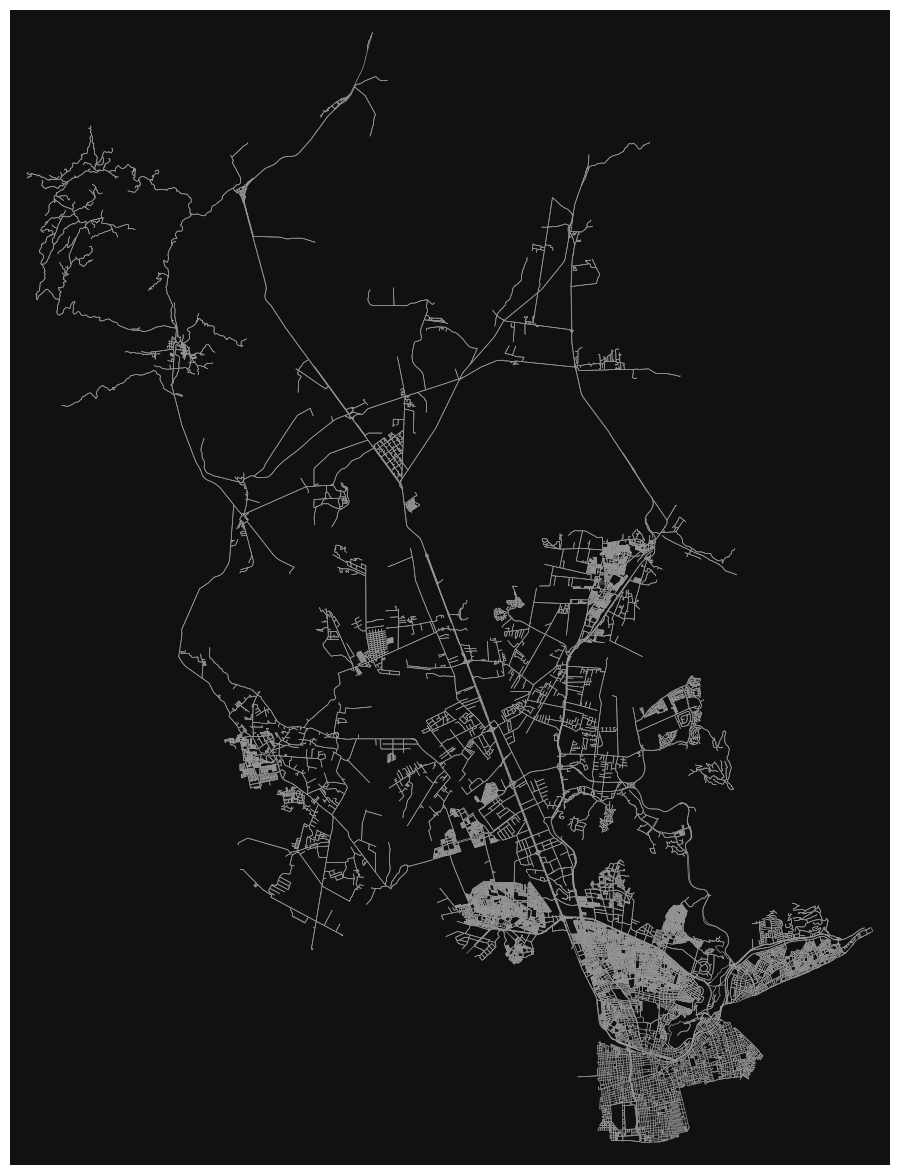

El grafo tiene 29261 nodos y 68637 aristas.


<Axes: >

<Figure size 640x480 with 0 Axes>

In [15]:
# lista de comunas que queremos
comunas_deseadas = ['Tiltil', 'Colina', 'Huechuraba', 'Lampa', 'Providencia', 'Vitacura', 'Independencia', 'Recoleta', 'Conchalí', 'Quilicura', 'Santiago']

# filtramos las comunas deseadas
comunas_filtradas = comunas[comunas['Comuna'].isin(comunas_deseadas)]

# asegurarse de que el CRS esté en EPSG:4326
comunas_filtradas = comunas_filtradas.to_crs(epsg=4326)

# unir todos los polígonos en uno solo
poligono_unido = unary_union(comunas_filtradas.geometry)

# obtener el grafo de OSMnx usando el polígono unido
G_drive = ox.graph_from_polygon(poligono_unido, network_type='drive')

# se visualiza el grafo
fig, ax = ox.plot_graph(G_drive, figsize=(15, 15), node_size=0, edge_linewidth=0.5)

print(f"El grafo tiene {len(G_drive.nodes)} nodos y {len(G_drive.edges)} aristas.")
comunas_filtradas.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

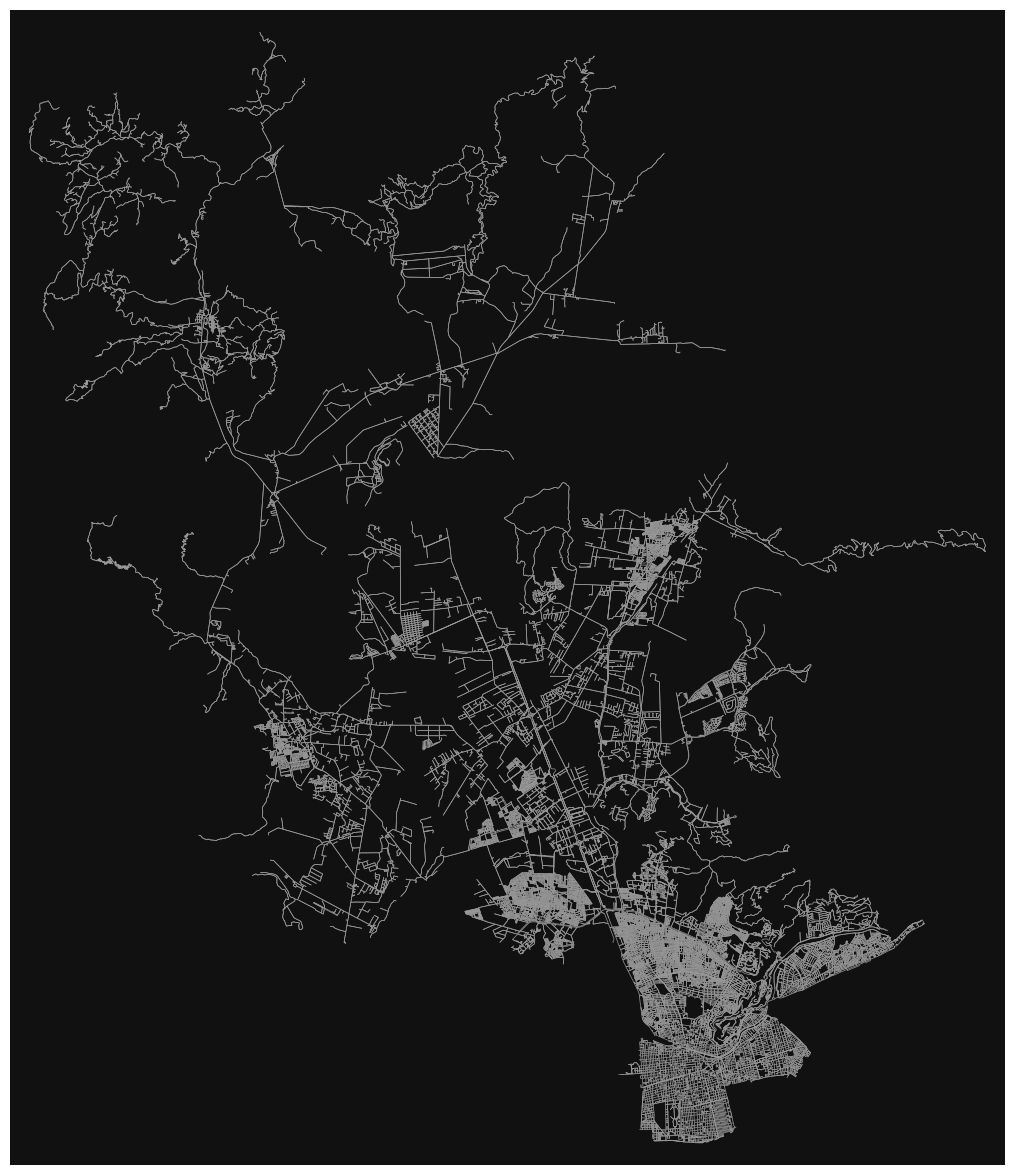

El grafo tiene 39586 nodos y 92193 aristas.


<Axes: >

<Figure size 640x480 with 0 Axes>

In [16]:
# ahora se obtiene el grafo de bicicletas
G_bike = ox.graph_from_polygon(poligono_unido, network_type='bike')

fig, ax = ox.plot_graph(G_bike, figsize=(15, 15), node_size=0, edge_linewidth=0.5)

print(f"El grafo tiene {len(G_bike.nodes)} nodos y {len(G_bike.edges)} aristas.")
# Si quieres visualizar los límites de las comunas sobre el grafo:
comunas_filtradas.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

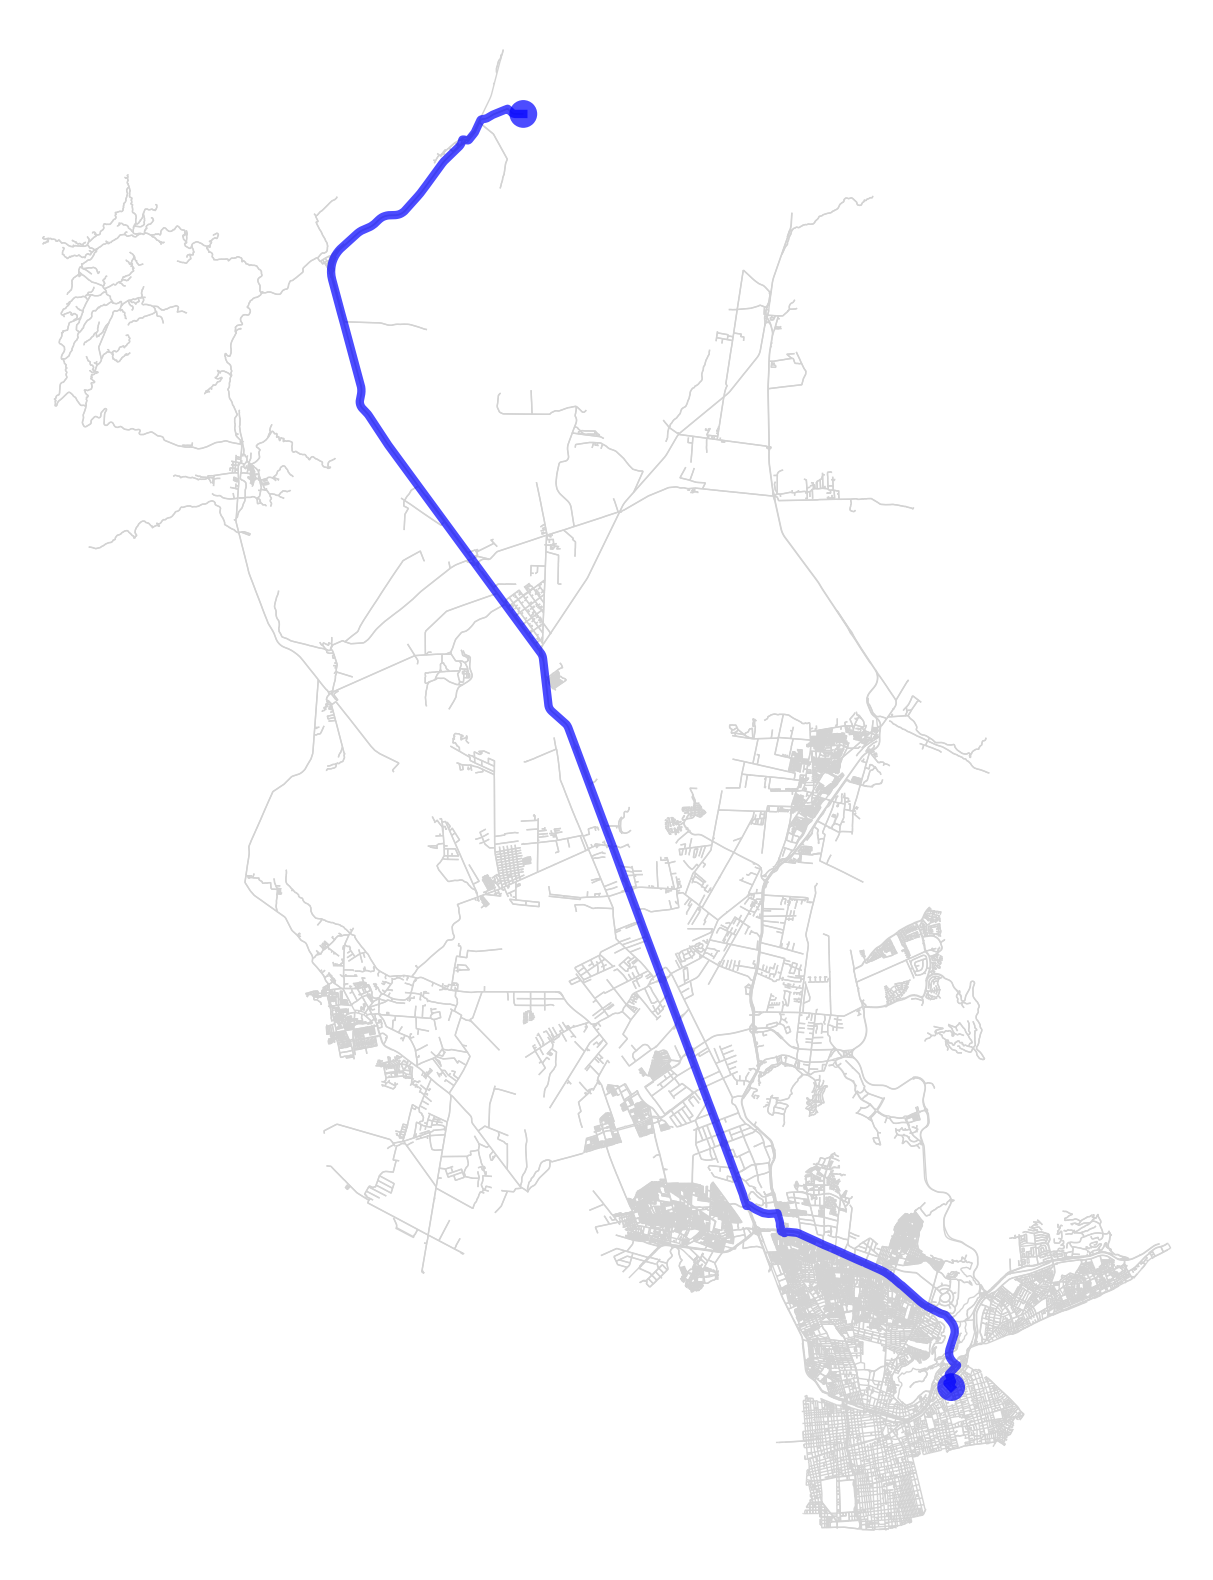

(<Figure size 3000x2000 with 1 Axes>, <Axes: >)

In [17]:
# ahora, con todo ya listo, podemos calcular la ruta más corta entre dos puntos
origen_coords = (distrito_min['geometry'].centroid.y, distrito_min['geometry'].centroid.x)
destino_coords = (distrito_max['geometry'].centroid.y, distrito_max['geometry'].centroid.x)

# recordar que se trabaja con nodos, por lo que se necesita encontrar el nodo más cercano a las coordenadas
nodo_origen = ox.nearest_nodes(G_drive, origen_coords[1], origen_coords[0])
nodo_destino = ox.nearest_nodes(G_drive, destino_coords[1], destino_coords[0])

ruta_auto = nx.shortest_path(G_drive, nodo_origen, nodo_destino, weight='length')
fig, ax = plt.subplots(figsize=(15, 10), dpi=200)
ox.plot_graph(G_drive, ax=ax, show=False, close=False, edge_color='lightgray', edge_linewidth=0.5, node_size=0)
ox.plot_graph_route(G_drive, ruta_auto, ax=ax, route_color='blue', route_linewidth=3, route_alpha=0.7, orig_dest_node_size=0)



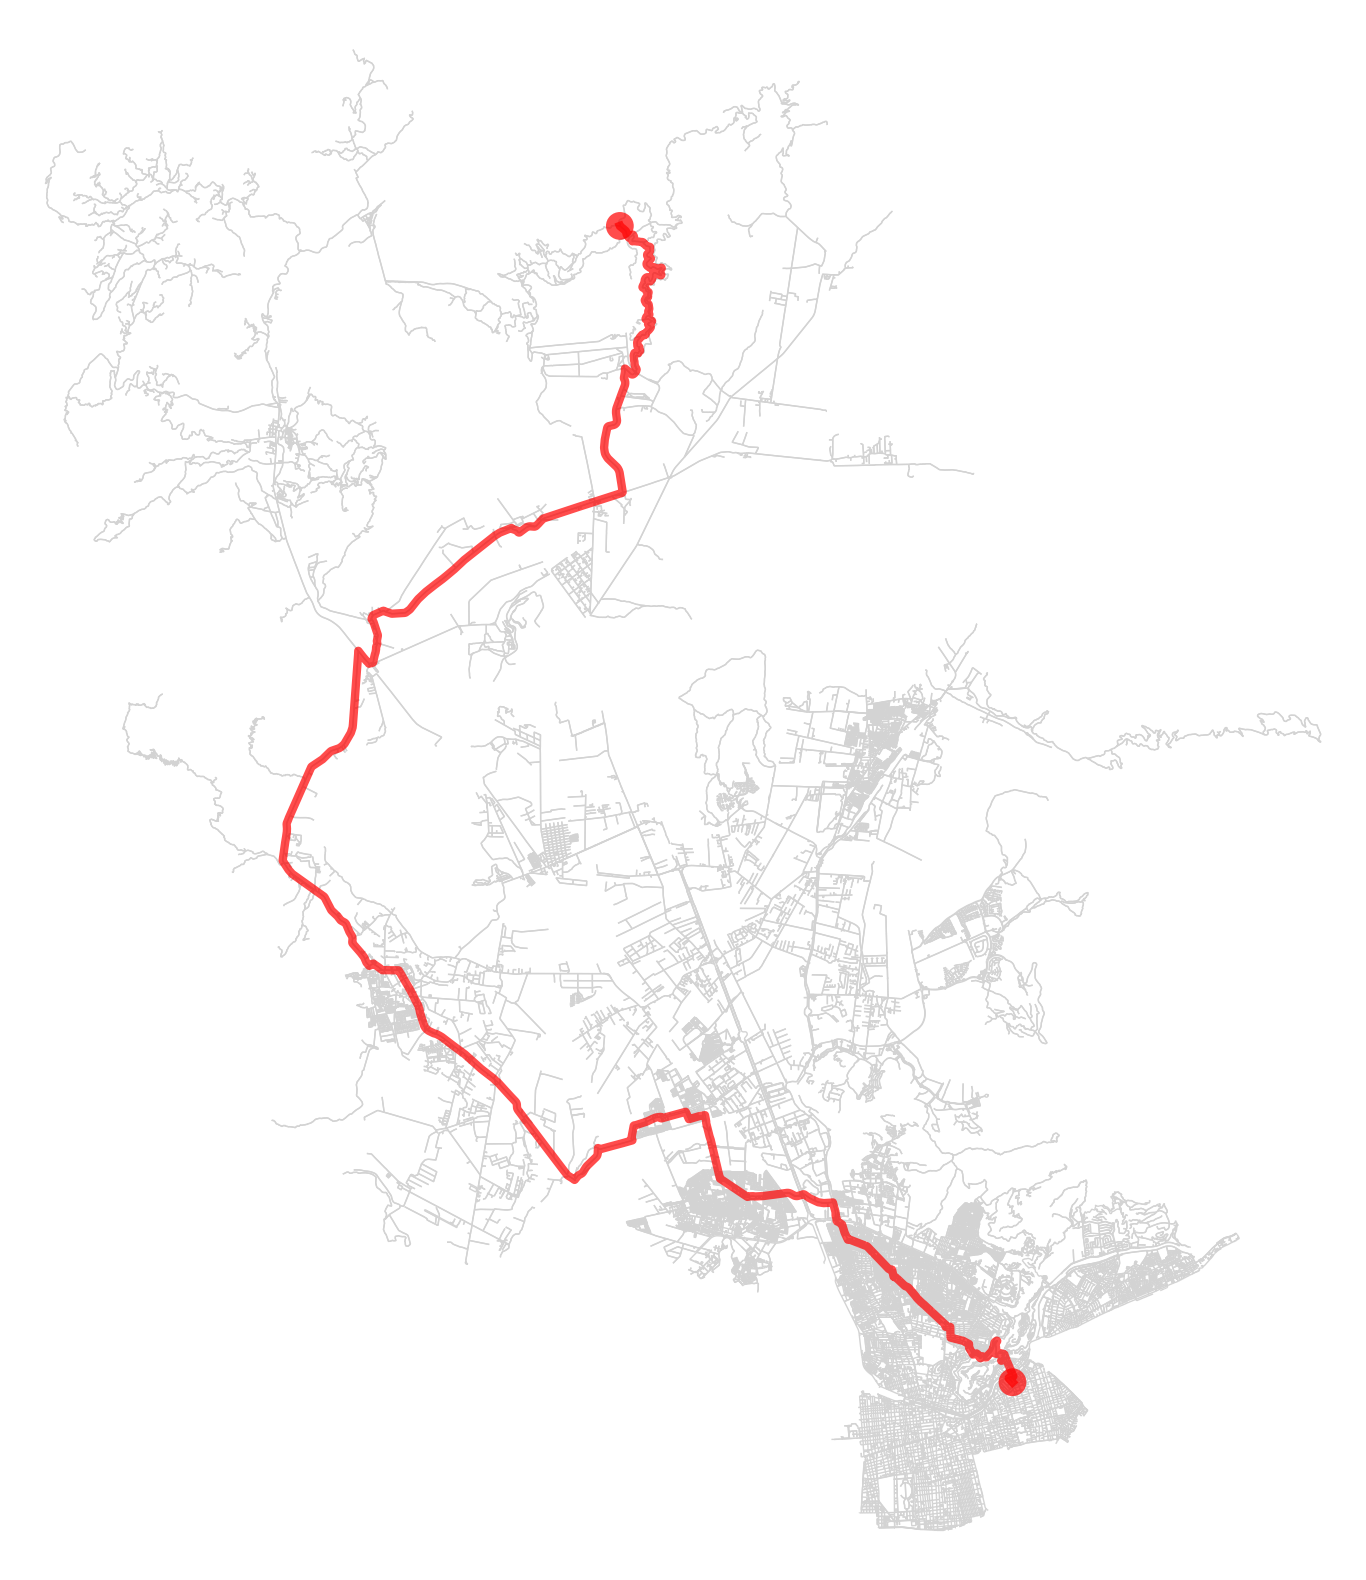

(<Figure size 3000x2000 with 1 Axes>, <Axes: >)

In [18]:
# ahora, se puede hacer lo mismo pero con bicicletas
nodo_origen = ox.nearest_nodes(G_bike, origen_coords[1], origen_coords[0])
nodo_destino = ox.nearest_nodes(G_bike, destino_coords[1], destino_coords[0])

# Obtener la ruta más corta basada en la longitud de las calles
ruta_bike = nx.shortest_path(G_bike, nodo_origen, nodo_destino, weight='length')
fig, ax = plt.subplots(figsize=(15, 10), dpi=200)
ox.plot_graph(G_bike, ax=ax, show=False, close=False, edge_color='lightgray', edge_linewidth=0.5, node_size=0)
ox.plot_graph_route(G_bike, ruta_bike, ax=ax, route_color='red', route_linewidth=3, route_alpha=0.7, orig_dest_node_size=0)



**c)**
Filtrando por las comunas de: Huechuraba, Providencia, Las Condes, La Reina, Ñuñoa, Vitacura, Independencia, Recoleta, Conchalí, Quilicura, Santiago, encuentre la ruta mínima que pase por:
- El centroide del distrito con más accidentes que involucran motocicletas.
- El centroide del distrito con menor densidad poblacional.
- El centroide del distrito con mayor percepción de seguridad.
- El centroide del distrito con mayor valor del suelo.

Identifique claramente el costo de cada tramo y el costo de la ruta completa, finalmente muestre gráficamente
la ruta obtenida.

Hint: Considere crear una versión simplificada de la red solo con 4 nodos y los seis arcos que los conectan
 con sus respectivos largos (obtenidos a partir de la red original), luego aplicar un algoritmo simple sobre
 esta nueva red para resolver el problema y finalmente incorporar los resultados en la red original.

In [19]:
# 1) motocicletas

# hacemos join
accidentes_por_distrito = gpd.sjoin(motocicletas_2019, distritos_censales, how='left', op='within')

# se cuenta el número de accidentes en cada distrito
accidentes_por_distrito_contados = accidentes_por_distrito.groupby('NOM_DIS').size().reset_index(name='num_accidentes')

# se une esta información al GeoDataFrame original de distritos censales
distritos_con_accidentes = distritos_censales.merge(accidentes_por_distrito_contados, on='NOM_DIS', how='left')

# se rellena NaN con 0 (distritos sin accidentes de motocicletas)
distritos_con_accidentes['num_accidentes'] = distritos_con_accidentes['num_accidentes'].fillna(0)

# encontrar el distrito con más accidentes de motocicletas
distrito_mas_accidentes = distritos_con_accidentes.loc[distritos_con_accidentes['num_accidentes'].idxmax()]

# obtener el centroide del distrito
centroide_motocicletas = distrito_mas_accidentes.geometry.centroid

print(f"El distrito con más accidentes que involucran motocicletas es: {distrito_mas_accidentes['NOM_DIS']}")
print(f"Coordenadas del centroide: {centroide_motocicletas.x}, {centroide_motocicletas.y}")

El distrito con más accidentes que involucran motocicletas es: Condell
Coordenadas del centroide: -70.6218397030749, -33.439804093386684


In [20]:
# 2) menor densidad poblacional.
distrito_menor_densidad = distritos_censales.loc[distritos_censales['Densidad'].idxmin()]

centroide_menor_densidad = distrito_menor_densidad.geometry.centroid

print(f"El distrito con menor densidad poblacional es: {distrito_menor_densidad['NOM_DIS']}")
print(f"Coordenadas del centroide: {centroide_menor_densidad.x}, {centroide_menor_densidad.y}")


El distrito con menor densidad poblacional es: Farellones
Coordenadas del centroide: -70.31100262750982, -33.32172526552272


In [ ]:
# 3) mayor percepción de seguridad.

seguridad_distritos = gpd.sjoin(seguridad, distritos_censales, how='left', op='within')

# agrupar por 'NOM_DIS' y calcular el promedio de 'seguridad' en cada distrito
promedio_seguridad_distritos = seguridad_distritos.groupby('NOM_DIS')['seguridad'].mean().reset_index()

# unir la información del promedio con los distritos censales originales
distritos_con_promedio = distritos_censales.merge(promedio_seguridad_distritos, on='NOM_DIS')

# encontrar el distrito con el mayor promedio de percepción de seguridad
distrito_mayor_seguridad = distritos_con_promedio.loc[distritos_con_promedio['seguridad'].idxmax()]

# obtener el centroide de ese distrito
centroide_mayor_seguridad = distrito_mayor_seguridad.geometry.centroid

print(f"El distrito con mayor percepción de seguridad es: {distrito_mayor_seguridad['NOM_DIS']}")
print(f"Coordenadas del centroide: {centroide_mayor_seguridad.x}, {centroide_mayor_seguridad.y}")

El distrito con mayor percepción de seguridad es: Estadio Manquehue
Coordenadas del centroide: -70.58194142931924, -33.390541130353256


In [22]:
# 4) mayor valor del suelo (1_UF_M2)
distrito_mayor_valor_suelo = distritos_censales.loc[distritos_censales['1_UF_M2'].idxmax()]

centroide_mayor_valor_suelo = distrito_mayor_valor_suelo.geometry.centroid

print(f"El distrito con mayor valor del suelo es: {distrito_mayor_valor_suelo['NOM_DIS']}")
print(f"Coordenadas del centroide: {centroide_mayor_valor_suelo.x}, {centroide_mayor_valor_suelo.y}")


El distrito con mayor valor del suelo es: Hospital Militar
Coordenadas del centroide: -70.6148802458927, -33.42341345620792


In [23]:
# se obtienen los nodos más cercanos para cada centroide
nodo_motocicletas = ox.nearest_nodes(G_drive, centroide_motocicletas.x, centroide_motocicletas.y)
nodo_menor_densidad = ox.nearest_nodes(G_drive, centroide_menor_densidad.x, centroide_menor_densidad.y)
nodo_mayor_seguridad = ox.nearest_nodes(G_drive, centroide_mayor_seguridad.x, centroide_mayor_seguridad.y)
nodo_mayor_valor_suelo = ox.nearest_nodes(G_drive, centroide_mayor_valor_suelo.x, centroide_mayor_valor_suelo.y)

# se crea una lista con todos los nodos
nodos_centroides = [nodo_motocicletas, nodo_menor_densidad, nodo_mayor_seguridad, nodo_mayor_valor_suelo]

In [24]:
# se crea un grafo vacío
subgrafo = nx.Graph()

for i in range(len(nodos_centroides)):
    for j in range(i + 1, len(nodos_centroides)):
        nodo_origen = nodos_centroides[i]
        nodo_destino = nodos_centroides[j]
        
        ruta = nx.shortest_path(G_drive, nodo_origen, nodo_destino, weight='length')
        
        costo = nx.shortest_path_length(G_drive, nodo_origen, nodo_destino, weight='length')
        
        # agregar el tramo al subgrafo con el costo
        subgrafo.add_edge(nodo_origen, nodo_destino, weight=costo)

print(f"Subgrafo con {len(subgrafo.nodes)} nodos y {len(subgrafo.edges)} aristas.")


Subgrafo con 4 nodos y 6 aristas.


In [25]:
# dado que son muy pocos nodos y aristas, fuerza bruta sera rapido
# fuerza bruta para calcular ruta con menor costo que pasa por todos los nodos
def brute_force_tsp(G):
    nodes = list(G.nodes)
    all_routes = permutations(nodes)
    min_cost = float('inf')
    best_route = None
    for route in all_routes:
        try:
            cost = sum(G[route[i]][route[i+1]]['weight'] for i in range(len(route) - 1))
            if cost < min_cost:
                min_cost = cost
                best_route = route
        except KeyError: # se ignoran rutas que no sean posibles debido a la falta de aristas
            continue
    return best_route, min_cost

mejor_ruta, costo_minimo = brute_force_tsp(subgrafo)

print(f"La mejor ruta es: {mejor_ruta} con un costo total de {costo_minimo}.")


La mejor ruta es: (434285066, 11556440915, 5361362363, 9671255398) con un costo total de 15866.799.


In [26]:
# para esa ruta, encontrar el costo de cada tramo
costos = [subgrafo[mejor_ruta[i]][mejor_ruta[i+1]]['weight'] for i in range(len(mejor_ruta) - 1)]

for i, tramo in enumerate(zip(mejor_ruta[:-1], mejor_ruta[1:])):
    origen, destino = tramo
    costo = costos[i]
    print(f"Tramo {i + 1}: De {origen} a {destino}, costo: {costo:.2f} metros.")

print(f"\nCosto total de la ruta: {sum(costos)} metros.")

Tramo 1: De 434285066 a 11556440915, costo: 2950.67 metros.
Tramo 2: De 11556440915 a 5361362363, costo: 5535.78 metros.
Tramo 3: De 5361362363 a 9671255398, costo: 7380.35 metros.

Costo total de la ruta: 15866.799 metros.


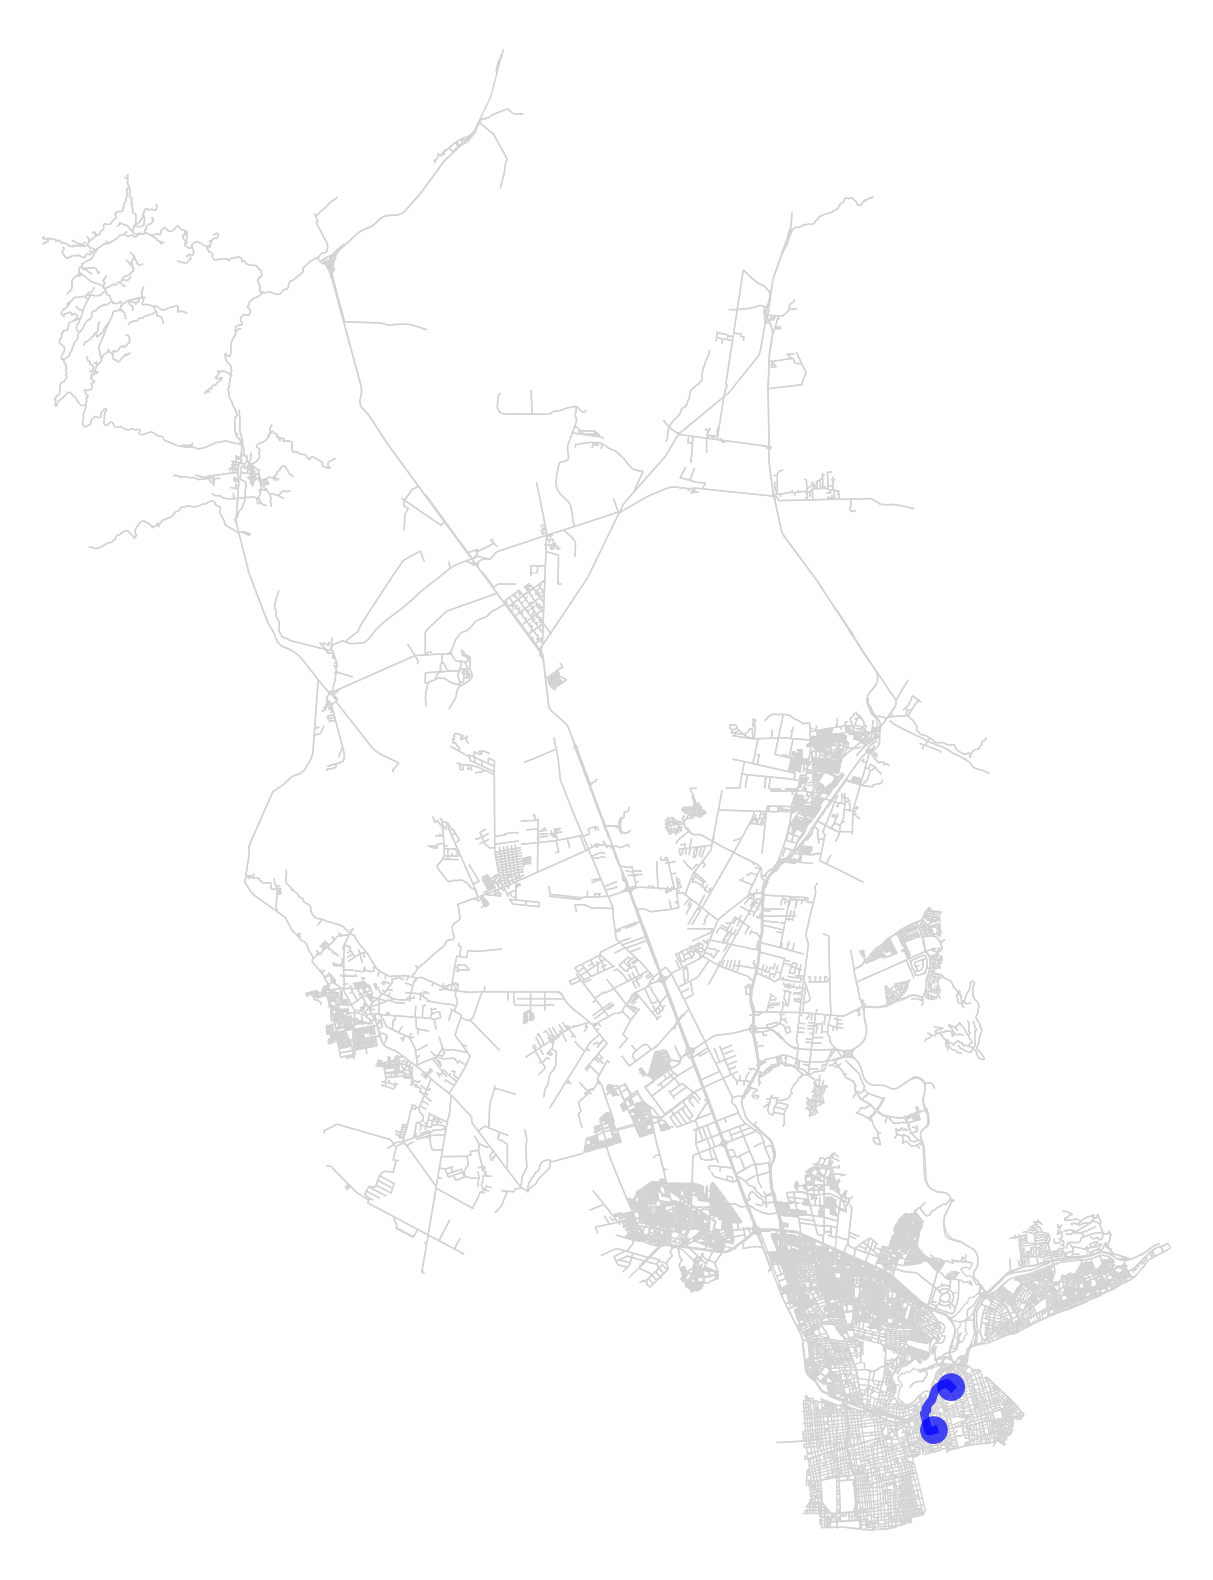

In [27]:
fig, ax = plt.subplots(figsize=(15, 10), dpi=200)
ox.plot_graph(G_drive, ax=ax, show=False, close=False, edge_color='lightgray', edge_linewidth=0.5, node_size=0)

# para almacenar las coordenadas de los nodos de la ruta
x_coords = []
y_coords = []

for i in range(len(mejor_ruta) - 1):
    nodo_origen = mejor_ruta[i]
    nodo_destino = mejor_ruta[i + 1]
    
    ruta_optima = nx.shortest_path(G_drive, nodo_origen, nodo_destino, weight='length')
    
    for nodo in ruta_optima:
        x, y = G_drive.nodes[nodo]['x'], G_drive.nodes[nodo]['y']
        x_coords.append(x)
        y_coords.append(y)
    
    ox.plot_graph_route(G_drive, ruta_optima, ax=ax, route_color='blue', route_linewidth=3, route_alpha=0.7, orig_dest_node_size=50, orig_dest_node_color='red')

ax.set_xlim([min(x_coords) - 0.005, max(x_coords) + 0.005])
ax.set_ylim([min(y_coords) - 0.005, max(y_coords) + 0.005])

ax.scatter(x_coords, y_coords, color='red', s=50, zorder=5, label='Nodos de la ruta')

ax.legend()

plt.show()
